In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

import bbrl_utils
from bbrl_utils.notebook import setup_tensorboard
from bbrl.stats import WelchTTest

import gymnasium as gym
import bbrl_gymnasium

from pmind.algorithms import DQN, DDPG, TD3
from pmind.losses import dqn_compute_critic_loss, ddqn_compute_critic_loss
from pmind.training import run_dqn, run_ddpg, run_td3
from pmind.config.loader import load_config

from pmind.replay import mix_transitions

from pmind.plot.policies import plot_rb_space_coverage, plot_policy, plot_trajectories

from pmind.plot.policies import ENV_NAMES, ALL_STATE_SPACES, ALL_STATE_NAMES, ALL_INIT_SPACES, EPISODE_LENGTHS

print("Supported environments are:", ENV_NAMES)

bbrl_utils.setup()

%load_ext autoreload
%autoreload 2

Supported environments are: ('CartPoleContinuous-v1', 'Pendulum-v1', 'MountainCarContinuous-v0')
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Set up state-action space information

Is specific for each environment

In [11]:
ENV_NAME = ENV_NAMES[2]

PENDULUM_ANGLE = (ENV_NAME == "Pendulum-v1")

ENV = gym.make(ENV_NAME)

MODELS_DIR = f"../models/{ENV_NAME}/"
STATE_NAMES = ALL_STATE_NAMES[ENV_NAME]
STATE_SPACE = ALL_STATE_SPACES[ENV_NAME]
INIT_SPACE = ALL_INIT_SPACES[ENV_NAME]
TRAJ_LENGTH = EPISODE_LENGTHS[ENV_NAME]

print(ENV_NAME)
print("state variables", STATE_NAMES)
print("bounded by:\n",STATE_SPACE)
print("initialized in:\n", INIT_SPACE)

MountainCarContinuous-v0
state variables ['position', 'velocity']
bounded by:
 [[-1.2   0.6 ]
 [-0.07  0.07]]
initialized in:
 [[-0.6 -0.4]
 [ 0.   0. ]]


In [12]:
# since we are limited to 2D, choose two state variables
STATE_X = 0
STATE_Y = 1
if PENDULUM_ANGLE:
    print("Chosen for plot: angle and anular velocity")
else:
    print(f"Chosen for plot: {STATE_NAMES[STATE_X]} and {STATE_NAMES[STATE_Y]}")

Chosen for plot: position and velocity


In [22]:
performances = torch.load("/Users/vlad/Documents/University/Master-MIND/projet-mind/experiments/results/test_rb_compositions-2026-04-05-220419/uniform_proportions-MountainCarContinuous-v0-scoring-86", weights_only=False)
best_policies = performances["best_policies"]
replay_buffers = performances["replay_buffers"]

# Visualize replay buffers

In [60]:
rb_unif = torch.load(MODELS_DIR + "unif-rb.pt", weights_only=False)
rb_best = torch.load(MODELS_DIR + "rb-86.pt", weights_only=False)
rb = mix_transitions(rb_unif, rb_best, buffer_size=200_000, proportion=0)

# rb = replay_buffers[0][0]

<Axes: title={'center': 'Replay buffer state-action space coverage'}, xlabel='position', ylabel='velocity'>

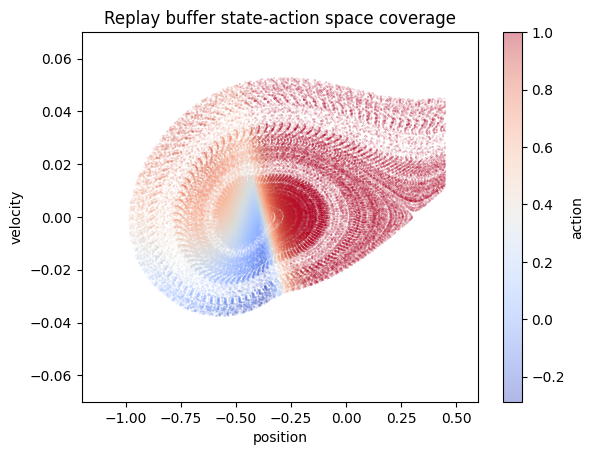

In [61]:
plot_rb_space_coverage(
    rb=rb,
    state_x=STATE_X,
    state_y=STATE_Y,
    state_names=STATE_NAMES,
    state_space=STATE_SPACE,
    pendulum_angle=PENDULUM_ANGLE
)

# Visualize learned policies

In [56]:
# policies = torch.load(MODELS_DIR + "intermediate-policies.pt", weights_only=False)
# policies.append(torch.load(MODELS_DIR + "best-policy.pt", weights_only=False))
# policies = [item for item in policies if item is not None]

# policies = dict(policies)  # expected format is dict[reward, policy]
policies = {86: best_policies[1][0]}

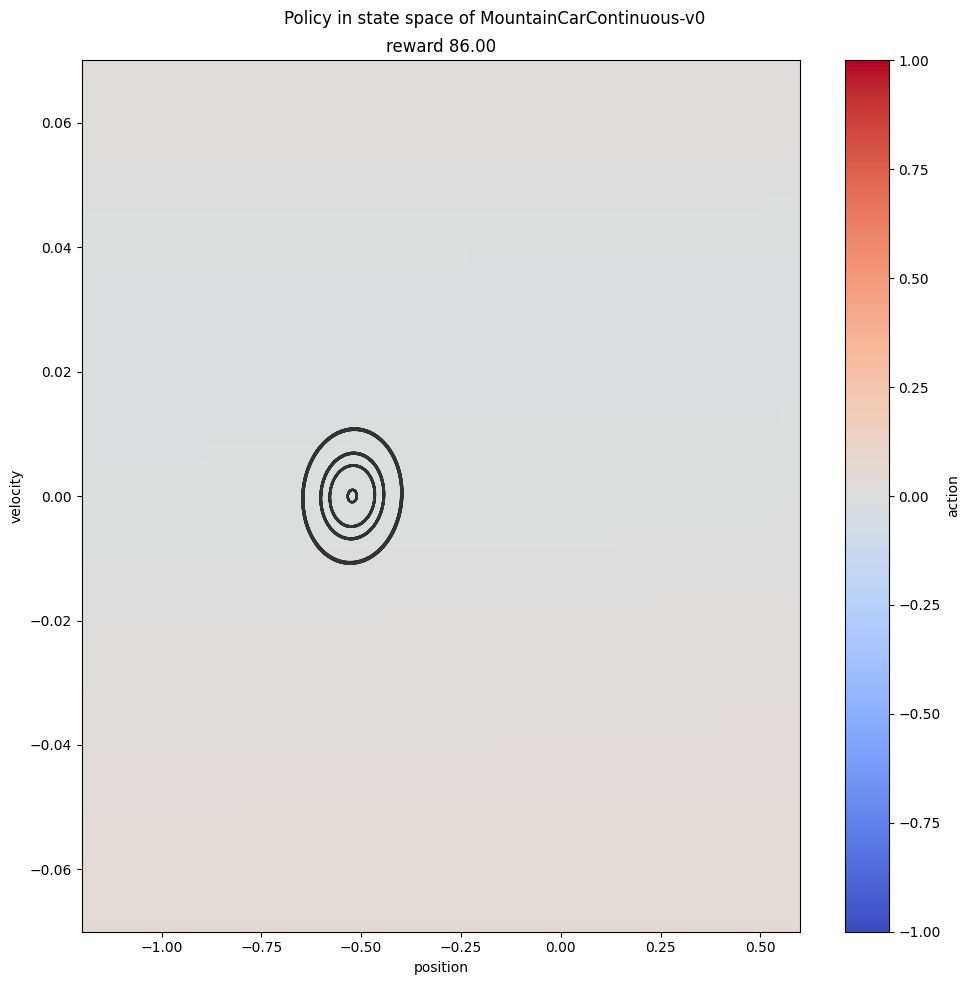

In [62]:
NB_TRAJ = 4

n_rewards = len(policies)
ncols = 2 if n_rewards > 1 else 1
nrows = int(np.ceil(n_rewards / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 10),subplot_kw={"projection": "polar"} if PENDULUM_ANGLE else None)

axes = np.atleast_1d(axes).flatten()

for i, (reward, policy) in enumerate(sorted(policies.items())):
    plot_policy(
        policy,
        state_x=STATE_X,
        state_y=STATE_Y,
        state_space=STATE_SPACE,
        fixed_state=None, 
        state_names=STATE_NAMES,
        ax=axes[i],
        pendulum_angle=PENDULUM_ANGLE
    )

    plot_trajectories(
        env=ENV,
        policy=policy,
        init_space=INIT_SPACE,
        nb_traj=NB_TRAJ,
        traj_length=TRAJ_LENGTH,
        state_x=STATE_X,
        state_y=STATE_Y,
        state_names=STATE_NAMES,
        ax=axes[i],
        pendulum_angle=PENDULUM_ANGLE
    )
    axes[i].set_title(f"reward {reward:.2f}")

for ax in axes[i + 1 :]:
    fig.delaxes(ax)

plt.suptitle(f"Policy in state space of {ENV_NAME}")
plt.tight_layout()
plt.show()

# Visualize learned Q-values

## TODO: get critic as well, not only actor

# SANDBOX

In [20]:
# for ENV_NAME in ENV_NAMES:
#     ENV = gym.make(ENV_NAME)
#     STATE_SPACE = np.array([ENV.observation_space.low, ENV.observation_space.high]).T
#     print({ENV_NAME: STATE_SPACE})